<a href="https://colab.research.google.com/github/Jishafranklin/Parallel-Project-HR-Employee-Attrition-Preprocessing/blob/gouri-missing-values/notebooks/HR_Employee_Attrition_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading & Initial Exploration
## Team Member: Jisha

### Purpose
This section loads the HR Employee Attrition dataset and performs initial exploration to understand:
- Dataset structure (rows, columns, data types)
- Quality of data (missing values, duplicates)
- Target variable distribution
- Basic statistical properties
- Which columns are numeric vs categorical

### Dataset Source
[IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options to see all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/ict_aiml/datasets/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Check number of rows and columns
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 1470 rows and 35 columns


In [12]:
# Check data types of each column
print("Data Types:\n")
print(df.dtypes)

Data Types:

Age                         int64
Attrition                  object
BusinessTravel             object
DailyRate                   int64
Department                 object
                            ...  
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLastPromotion     int64
YearsWithCurrManager        int64
Length: 35, dtype: object


In [13]:
# Get comprehensive info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [14]:
# Statistical summary of numeric columns
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [15]:
# Check the target variable - Attrition

print("Attrition Value Counts:")
print(df['Attrition'].value_counts())

print("\nAttrition Percentages:")
print((df['Attrition'].value_counts(normalize=True) * 100).round(2))


Attrition Value Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentages:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


In [16]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical columns:")
print(categorical_cols.tolist())




Categorical columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [17]:
# Display unique values for each categorical column
for col in categorical_cols:
    print("\n",col, ":", df[col].unique())


 Attrition : ['Yes' 'No']

 BusinessTravel : ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

 Department : ['Sales' 'Research & Development' 'Human Resources']

 EducationField : ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

 Gender : ['Female' 'Male']

 JobRole : ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

 MaritalStatus : ['Single' 'Married' 'Divorced']

 Over18 : ['Y']

 OverTime : ['Yes' 'No']


In [18]:
# Check the number of unique values in each column
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
...,...
WorkLifeBalance,4
YearsAtCompany,37
YearsInCurrentRole,19
YearsSinceLastPromotion,16


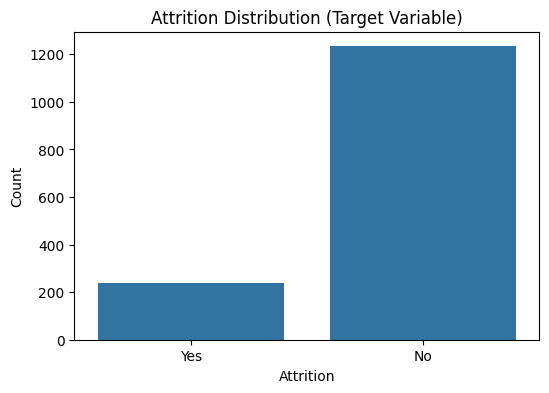

In [19]:
# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition')
plt.title('Attrition Distribution (Target Variable)')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

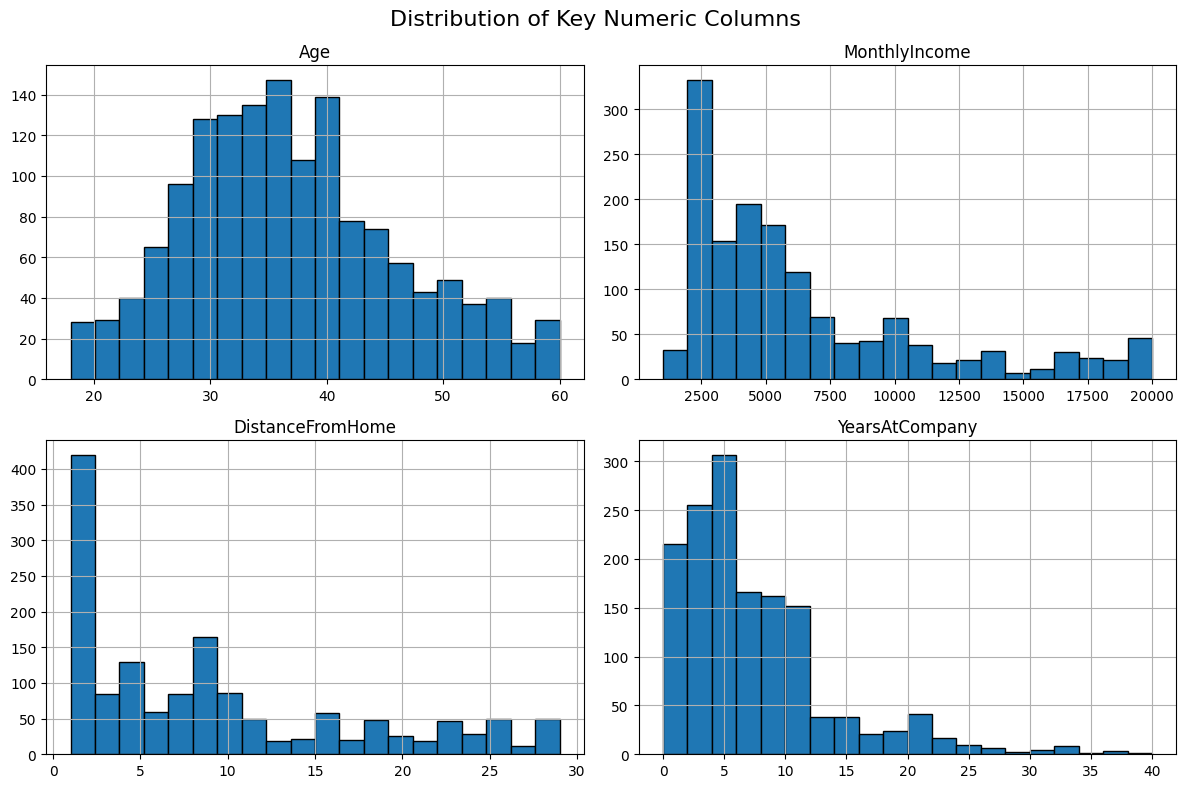

In [20]:
# Quick histogram of key numeric columns
numeric_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany']
df[numeric_cols].hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle('Distribution of Key Numeric Columns', size=16)
plt.tight_layout()
plt.show()

## 📌 Initial Observations

### Dataset Overview
- **Total Records:** 1,470 employees
- **Total Features:** 35 columns
- **Target Variable:** `Attrition` (Yes = employee left, No = employee stayed)

### Data Types
- **Numeric Columns (int64):** Age, DailyRate, DistanceFromHome, Education, EmployeeNumber, EnvironmentSatisfaction, HourlyRate, JobInvolvement, JobLevel, JobSatisfaction, MonthlyIncome, MonthlyRate, NumCompaniesWorked, PercentSalaryHike, PerformanceRating, RelationshipSatisfaction, StandardHours, StockOptionLevel, TotalWorkingYears, TrainingTimesLastYear, WorkLifeBalance, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager
- **Categorical Columns (object):** Attrition, BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus, Over18, OverTime

### Target Variable Analysis
- **Attrition 'No':** ~1,233 employees (83.9%)
- **Attrition 'Yes':** ~237 employees (16.1%)
- **Observation:** There is significant class imbalance. This should be considered during modeling.

### Initial Data Quality Observation

- `df.info()` shows that all 1,470 records are non-null.
- A detailed missing-value analysis and Duplicate and data consistency checks will be performed by the respective team members.



### Key Numeric Column Ranges
- **Age:** 18 to 60 years
- **MonthlyIncome:** ~1,000 to ~20,000
- **DistanceFromHome:** 1 to 29 miles
- **YearsAtCompany:** 0 to 40 years
- **TotalWorkingYears:** 0 to 40 years

### Next Steps
- Gouri will perform missing value analysis
- Meenaskshi will handle duplicates & data consistency


### Conclusion

The initial exploration provides an understanding of the dataset structure, variable types, target distribution, and basic numerical distributions. Further preprocessing steps will be performed by the respective team members.

# Handling Missing Values

**Dataset:** IBM HR Analytics Employee Attrition & Performance

**Contribution:** Gouri

## Objective
To identify and handle missing values in the dataset.

In [21]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
...,...
WorkLifeBalance,0
YearsAtCompany,0
YearsInCurrentRole,0
YearsSinceLastPromotion,0


In [22]:
df.isna().mean() * 100

,0
Age,0.0
Attrition,0.0
BusinessTravel,0.0
DailyRate,0.0
Department,0.0
...,...
WorkLifeBalance,0.0
YearsAtCompany,0.0
YearsInCurrentRole,0.0
YearsSinceLastPromotion,0.0


In [23]:
df.isna().sum().sum()

np.int64(0)

## Conclusion

The dataset was analyzed for missing values. No missing values were found, so no imputation or deletion was required. The dataset is ready for the next preprocessing stage.
